In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
chethuhn_network_intrusion_dataset_path = kagglehub.dataset_download('chethuhn/network-intrusion-dataset')

print('Data source import complete.')


Part 2.2 - CICIDS 2017 Tabular GAN

1. Imports & Setup

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)


Device: cuda


2. Load CICIDS 2017 Wednesday File

In [ ]:
CSV_PATH = '/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Wednesday-workingHours.pcap_ISCX.csv'  # update path if needed

df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()
print('Raw shape:', df.shape)
print('Label distribution:')
label_col = 'Label' if 'Label' in df.columns else ' Label'
print(df[label_col].value_counts())


Raw shape: (692703, 79)
Label distribution:
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64


3. Explore and Preprocess

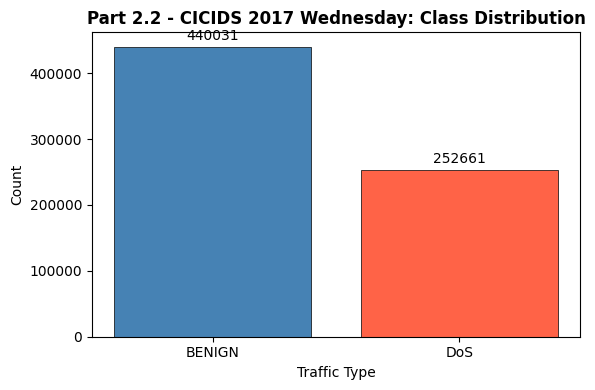

In [ ]:
df[label_col] = df[label_col].str.strip()
target_labels = ['BENIGN','DoS Hulk','DoS GoldenEye','DoS slowloris','DoS Slowhttptest']
df = df[df[label_col].isin(target_labels)].copy()
df[label_col] = df[label_col].apply(lambda x: 'DoS' if x!='BENIGN' else 'BENIGN')

fig, ax = plt.subplots(figsize=(6,4))
counts = df[label_col].value_counts()
bars = ax.bar(counts.index, counts.values, color=['steelblue','tomato'],
              edgecolor='black', linewidth=0.5)
ax.bar_label(bars, padding=3)
ax.set_title('Part 2.2 - CICIDS 2017 Wednesday: Class Distribution', fontweight='bold')
ax.set_xlabel('Traffic Type'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()


4. Feature Engineering

In [ ]:
drop_cols = [label_col,'Flow ID','Source IP','Destination IP',
             'Source Port','Destination Port','Protocol','Timestamp']
drop_cols = [c for c in drop_cols if c in df.columns]
X = df.drop(columns=drop_cols)
y = (df[label_col]=='DoS').astype(int).values

X = X.replace([np.inf,-np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))
X = X.select_dtypes(include=[np.number])

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X.values).astype(np.float32)
INPUT_DIM = X_scaled.shape[1]
print(f'Features: {INPUT_DIM} | Samples: {X_scaled.shape[0]}')
print(f'BENIGN: {(y==0).sum()} | DoS: {(y==1).sum()}')


Features: 77 | Samples: 692692
BENIGN: 440031 | DoS: 252661


5. Create DataLoader

In [ ]:
X_tensor = torch.from_numpy(X_scaled)
y_tensor = torch.from_numpy(y).float()
dataset  = TensorDataset(X_tensor, y_tensor)

BATCH_SIZE   = 512  # large batch for GPU speed
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                          drop_last=True, num_workers=2, pin_memory=True)
print(f'Dataset: {len(dataset)} | Batches/epoch: {len(train_loader)}')


Dataset: 692692 | Batches/epoch: 1352


6. Tabular GAN Model Definitions

In [ ]:
LATENT_DIM = 64

class TabGenerator(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim,128), nn.LeakyReLU(0.2),
            nn.Linear(128,256),        nn.LeakyReLU(0.2),
            nn.Linear(256,512),        nn.LeakyReLU(0.2),
            nn.Linear(512,output_dim), nn.Tanh(),
        )
    def forward(self,z): return self.net(z)


class TabDiscriminator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim,512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(512,256),       nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(256,128),       nn.LeakyReLU(0.2),
            nn.Linear(128,1),         nn.Sigmoid(),
        )
    def forward(self,x): return self.net(x)


tab_generator     = TabGenerator(LATENT_DIM, INPUT_DIM).to(DEVICE)
tab_discriminator = TabDiscriminator(INPUT_DIM).to(DEVICE)
print(f'Generator     : {sum(p.numel() for p in tab_generator.parameters()):,} params')
print(f'Discriminator : {sum(p.numel() for p in tab_discriminator.parameters()):,} params')


Generator     : 212,429 params
Discriminator : 204,289 params


7. Train Tabular GAN

In [ ]:
LR         = 0.0002
BETAS      = (0.5, 0.999)
NUM_EPOCHS = 200

opt_G   = torch.optim.Adam(tab_generator.parameters(),     lr=LR,     betas=BETAS)
opt_D   = torch.optim.Adam(tab_discriminator.parameters(), lr=LR*0.5, betas=BETAS)
loss_fn = nn.BCELoss()


def train_tabular_gan(generator, discriminator, loader, opt_G, opt_D,
                      loss_fn, num_epochs, latent_dim, device, print_every=20):
    g_losses, d_losses = [], []
    for epoch in range(num_epochs):
        g_epoch, d_epoch, n = 0.0, 0.0, 0
        for real_batch, _ in loader:
            real_batch = real_batch.to(device, non_blocking=True)
            bs = real_batch.size(0)
            real_labels = torch.full((bs,1), 0.9, device=device)  # label smoothing
            fake_labels = torch.zeros(bs, 1, device=device)

            z = torch.randn(bs, latent_dim, device=device)
            fake_batch = generator(z).detach()
            loss_d = loss_fn(discriminator(real_batch), real_labels) + \
                     loss_fn(discriminator(fake_batch), fake_labels)
            opt_D.zero_grad(); loss_d.backward(); opt_D.step()

            z = torch.randn(bs, latent_dim, device=device)
            fake_batch = generator(z)
            loss_g = loss_fn(discriminator(fake_batch), torch.ones(bs,1,device=device))
            opt_G.zero_grad(); loss_g.backward(); opt_G.step()

            g_epoch += loss_g.item(); d_epoch += loss_d.item(); n += 1

        g_losses.append(g_epoch/n); d_losses.append(d_epoch/n)
        if print_every < num_epochs and epoch % print_every == 0:
            print(f'Epoch {epoch:3d}/{num_epochs} | Loss G: {g_losses[-1]:.4f} | Loss D: {d_losses[-1]:.4f}')

    return g_losses, d_losses


g_losses, d_losses = train_tabular_gan(
    tab_generator, tab_discriminator, train_loader,
    opt_G, opt_D, loss_fn,
    num_epochs=NUM_EPOCHS, latent_dim=LATENT_DIM, device=DEVICE, print_every=20
)


Epoch   0/200 | Loss G: 1.4547 | Loss D: 0.9941
Epoch  20/200 | Loss G: 3.4718 | Loss D: 0.4846
Epoch  40/200 | Loss G: 3.4453 | Loss D: 0.4792
Epoch  60/200 | Loss G: 3.4858 | Loss D: 0.4737
Epoch  80/200 | Loss G: 3.5271 | Loss D: 0.4713
Epoch 100/200 | Loss G: 3.6030 | Loss D: 0.4691
Epoch 120/200 | Loss G: 3.7253 | Loss D: 0.4646
Epoch 140/200 | Loss G: 3.8078 | Loss D: 0.4628
Epoch 160/200 | Loss G: 3.8982 | Loss D: 0.4603
Epoch 180/200 | Loss G: 3.9983 | Loss D: 0.4579


8. Loss Curves

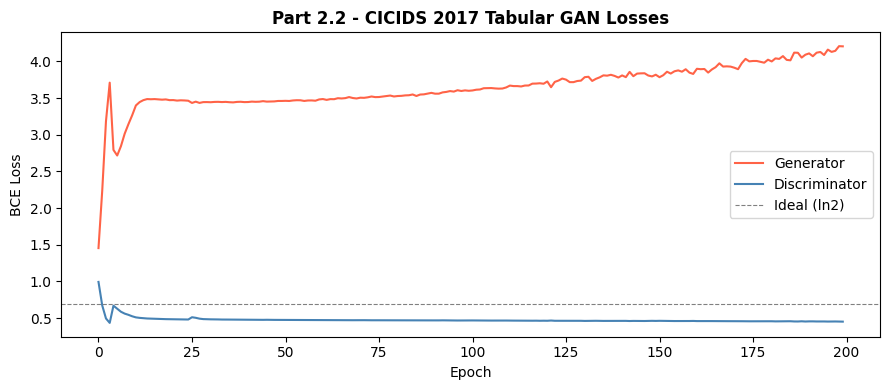

In [ ]:
import math
fig, ax = plt.subplots(figsize=(9,4))
ax.plot(g_losses, label='Generator',     color='tomato',    linewidth=1.5)
ax.plot(d_losses, label='Discriminator', color='steelblue', linewidth=1.5)
ax.axhline(y=math.log(2), color='grey', linestyle='--', linewidth=0.8, label='Ideal (ln2)')
ax.set_title('Part 2.2 - CICIDS 2017 Tabular GAN Losses', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss'); ax.legend()
plt.tight_layout(); plt.show()


9. Generate Synthetic Traffic Samples

In [ ]:
N_GENERATE = 5000
tab_generator.eval()
with torch.no_grad():
    fake_samples = tab_generator(torch.randn(N_GENERATE,LATENT_DIM,device=DEVICE)).cpu().numpy()
tab_generator.train()
print(f'Generated {N_GENERATE} synthetic feature vectors, shape: {fake_samples.shape}')


Generated 5000 synthetic feature vectors, shape: (5000, 77)


10. PCA Visualisation: Real vs Generated

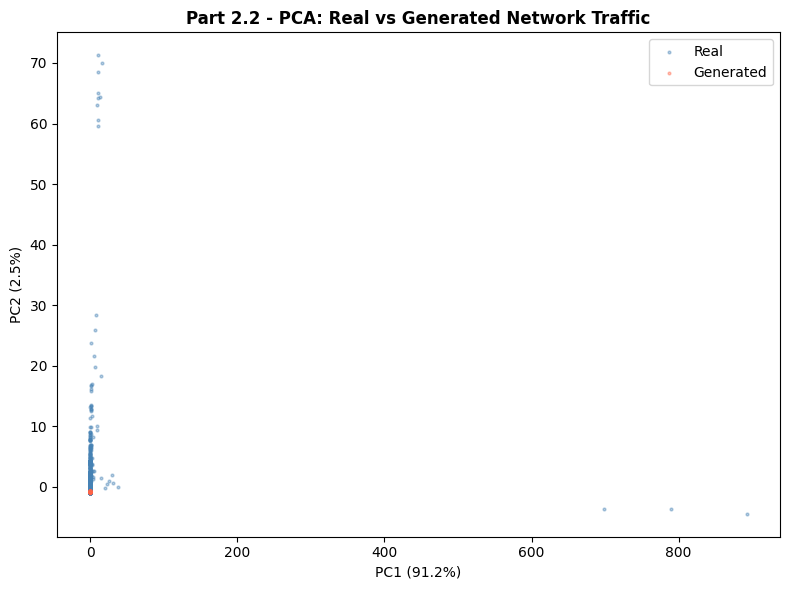

In [ ]:
N_VIS    = 2000
real_vis = X_scaled[:N_VIS]
fake_vis = fake_samples[:N_VIS]

combined    = np.vstack([real_vis, fake_vis])
pca         = PCA(n_components=2, random_state=42)
combined_2d = pca.fit_transform(combined)
real_2d, fake_2d = combined_2d[:N_VIS], combined_2d[N_VIS:]
explained = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(real_2d[:,0], real_2d[:,1], s=4, alpha=0.4, color='steelblue', label='Real')
ax.scatter(fake_2d[:,0], fake_2d[:,1], s=4, alpha=0.4, color='tomato',    label='Generated')
ax.set_title('Part 2.2 - PCA: Real vs Generated Network Traffic', fontweight='bold')
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
ax.legend(); plt.tight_layout(); plt.show()


11. t-SNE Visualisation

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


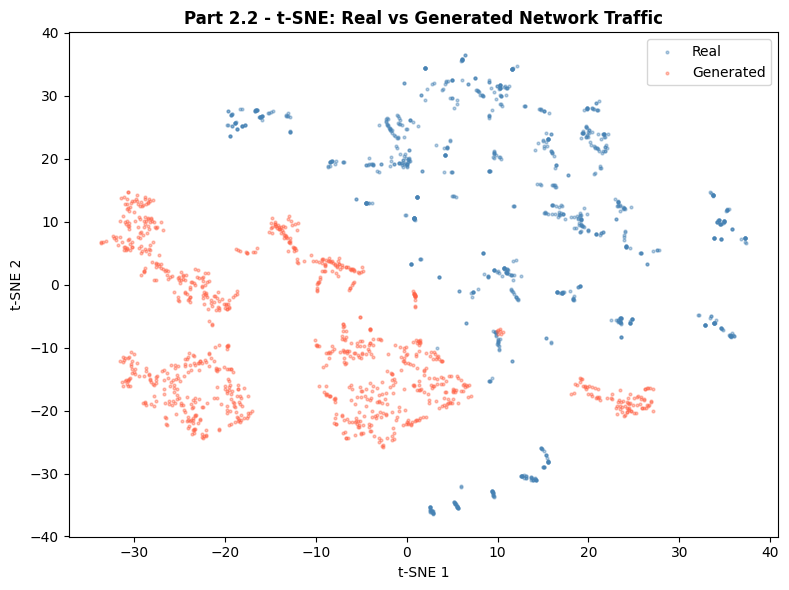

In [ ]:
N_TSNE       = 1000
combined_tsne = np.vstack([X_scaled[:N_TSNE], fake_samples[:N_TSNE]])
tsne          = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=500)
out_2d        = tsne.fit_transform(combined_tsne)
real_t, fake_t = out_2d[:N_TSNE], out_2d[N_TSNE:]

fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(real_t[:,0], real_t[:,1], s=4, alpha=0.4, color='steelblue', label='Real')
ax.scatter(fake_t[:,0], fake_t[:,1], s=4, alpha=0.4, color='tomato',    label='Generated')
ax.set_title('Part 2.2 - t-SNE: Real vs Generated Network Traffic', fontweight='bold')
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2'); ax.legend()
plt.tight_layout(); plt.show()


12. Feature Distribution Comparison

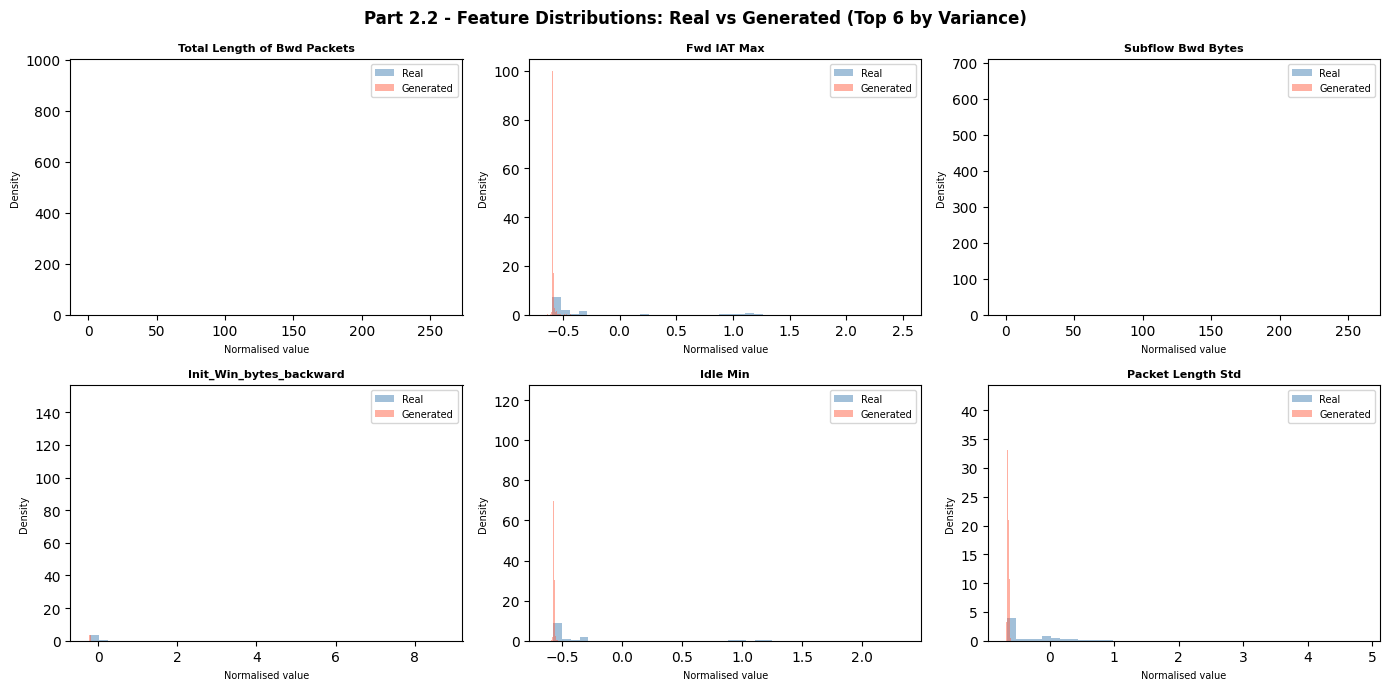

In [ ]:
feature_names = X.columns.tolist()
variances     = X_scaled.var(axis=0)
top6_idx      = np.argsort(variances)[::-1][:6]

fig, axes = plt.subplots(2,3, figsize=(14,7))
axes = axes.flatten()
for i, idx in enumerate(top6_idx):
    axes[i].hist(real_vis[:,idx], bins=40, alpha=0.5, color='steelblue', label='Real',      density=True)
    axes[i].hist(fake_vis[:,idx], bins=40, alpha=0.5, color='tomato',    label='Generated', density=True)
    axes[i].set_title(feature_names[idx][:30], fontsize=8, fontweight='bold')
    axes[i].set_xlabel('Normalised value', fontsize=7)
    axes[i].set_ylabel('Density', fontsize=7)
    axes[i].legend(fontsize=7)
plt.suptitle('Part 2.2 - Feature Distributions: Real vs Generated (Top 6 by Variance)', fontweight='bold')
plt.tight_layout(); plt.show()


## 13. Results Summary

In [ ]:
print('='*55)
print('PART 2.2 - CICIDS 2017 TABULAR GAN RESULTS SUMMARY')
print('='*55)
print(f'Dataset      : CICIDS 2017 Wednesday (BENIGN + DoS)')
print(f'Features     : {INPUT_DIM} | Samples: {len(X_scaled)}')
print(f'Architecture : MLP GAN (TabGenerator + TabDiscriminator)')
print(f'Latent dim   : {LATENT_DIM} | Epochs: {NUM_EPOCHS} | Batch: {BATCH_SIZE}')
print(f'Final Loss G : {g_losses[-1]:.4f} | Final Loss D: {d_losses[-1]:.4f}')

PART 2.2 - CICIDS 2017 TABULAR GAN RESULTS SUMMARY
Dataset      : CICIDS 2017 Wednesday (BENIGN + DoS)
Features     : 77 | Samples: 692692
Architecture : MLP GAN (TabGenerator + TabDiscriminator)
Latent dim   : 64 | Epochs: 200 | Batch: 512
Final Loss G : 4.2040 | Final Loss D: 0.4527
